# F1 Predictor

Our goal with this project is to reliably predict podiums better than using the heuristic that someone qualifying on the podium, will finish with a podium.

## Loading the Data, Setting up Libraries

Firstly, we need to load in the libraries that we're going to use, and also load in the downloaded CSV files. For this project we're using:
https://www.kaggle.com/datasets/jtrotman/formula-1-race-data

This is an export of all of the race data up to the current F1 race from Jolpica/Ergast, we could scrape those API's directly but there are rate limits involved which makes it more difficult to deal with and using the pre-made dataset makes us a better citizen.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, auc, brier_score_loss

### Race Data

This dataset uses "\N" as an NA value, so we need to set this when we load in the datasets. We also get Pandas to parse the dates as well on load for convenience, we could potentially convert the times for now but it's unlikely that they would be useful in our analysis

In [31]:
race_df = pd.read_csv("../data/races.csv", na_values="\\N", parse_dates=["date", "quali_date"])
race_df.info()
race_df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1171 entries, 0 to 1170
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   raceId       1171 non-null   int64         
 1   year         1171 non-null   int64         
 2   round        1171 non-null   int64         
 3   circuitId    1171 non-null   int64         
 4   name         1171 non-null   object        
 5   date         1171 non-null   datetime64[ns]
 6   time         440 non-null    object        
 7   url          1171 non-null   object        
 8   fp1_date     136 non-null    object        
 9   fp1_time     114 non-null    object        
 10  fp2_date     118 non-null    object        
 11  fp2_time     96 non-null     object        
 12  fp3_date     106 non-null    object        
 13  fp3_time     87 non-null     object        
 14  quali_date   136 non-null    datetime64[ns]
 15  quali_time   114 non-null    object        
 16  sprint

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
1166,1186,2026,18,32,Mexico City Grand Prix,2026-11-01,20:00:00,https://en.wikipedia.org/wiki/2026_Mexico_City...,2026-10-30,18:30:00,2026-10-30,22:00:00,2026-10-31,17:30:00,2026-10-31,21:00:00,NaN,NaN
1167,1187,2026,19,18,Brazilian Grand Prix,2026-11-08,17:00:00,https://en.wikipedia.org/wiki/2026_Brazilian_G...,2026-11-06,15:30:00,2026-11-06,19:00:00,2026-11-07,14:30:00,2026-11-07,18:00:00,NaN,NaN
1168,1188,2026,20,80,Las Vegas Grand Prix,2026-11-22,04:00:00,https://en.wikipedia.org/wiki/2026_Las_Vegas_G...,2026-11-20,00:30:00,2026-11-20,04:00:00,2026-11-21,00:30:00,2026-11-21,04:00:00,NaN,NaN
1169,1189,2026,21,78,Qatar Grand Prix,2026-11-29,16:00:00,https://en.wikipedia.org/wiki/2026_Qatar_Grand...,2026-11-27,13:30:00,2026-11-27,17:00:00,2026-11-28,14:30:00,2026-11-28,18:00:00,NaN,NaN
1170,1190,2026,22,24,Abu Dhabi Grand Prix,2026-12-06,13:00:00,https://en.wikipedia.org/wiki/2026_Abu_Dhabi_G...,2026-12-04,09:30:00,2026-12-04,13:00:00,2026-12-05,10:30:00,2026-12-05,14:00:00,NaN,NaN


### Qualifying Data

Samme as above, albeit there are no dates to parse on this one

In [32]:
quali_df = pd.read_csv("../data/qualifying.csv", na_values="\\N")
quali_df.info()
quali_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11036 entries, 0 to 11035
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   qualifyId      11036 non-null  int64 
 1   raceId         11036 non-null  int64 
 2   driverId       11036 non-null  int64 
 3   constructorId  11036 non-null  int64 
 4   number         11036 non-null  int64 
 5   position       11036 non-null  int64 
 6   q1             10873 non-null  object
 7   q2             6249 non-null   object
 8   q3             3893 non-null   object
dtypes: int64(6), object(3)
memory usage: 776.1+ KB


,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
0,1,18,1,1,22,1,1:26.572,1:25.187,1:26.714
1,2,18,9,2,4,2,1:26.103,1:25.315,1:26.869
2,3,18,5,1,23,3,1:25.664,1:25.452,1:27.079
3,4,18,13,6,2,4,1:25.994,1:25.691,1:27.178
4,5,18,2,2,3,5,1:25.960,1:25.518,1:27.236


### Race Result Data

In [33]:
res_df = pd.read_csv("../data/results.csv", na_values="\\N")
res_df.info()
res_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27304 entries, 0 to 27303
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         27304 non-null  int64  
 1   raceId           27304 non-null  int64  
 2   driverId         27304 non-null  int64  
 3   constructorId    27304 non-null  int64  
 4   number           27298 non-null  float64
 5   grid             27284 non-null  float64
 6   position         16351 non-null  float64
 7   positionText     27304 non-null  object 
 8   positionOrder    27304 non-null  int64  
 9   points           27304 non-null  float64
 10  laps             27304 non-null  int64  
 11  time             8052 non-null   object 
 12  milliseconds     8052 non-null   float64
 13  fastestLap       8769 non-null   float64
 14  rank             9027 non-null   float64
 15  fastestLapTime   8769 non-null   object 
 16  fastestLapSpeed  8252 non-null   float64
 17  statusId    

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1.0,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
1,2,18,2,2,3.0,5.0,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
2,3,18,3,3,7.0,7.0,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
3,4,18,4,4,5.0,11.0,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
4,5,18,5,1,23.0,3.0,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1


### Constructors Data

In [34]:
constructor_df = pd.read_csv("../data/constructors.csv")
constructor_df.info()
constructor_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   constructorId   214 non-null    int64 
 1   constructorRef  214 non-null    object
 2   name            214 non-null    object
 3   nationality     214 non-null    object
 4   url             214 non-null    object
dtypes: int64(1), object(4)
memory usage: 8.5+ KB


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


### Drivers Data

We parse out the DOB here as it might be useful in our analysis

In [35]:
drivers_df = pd.read_csv("../data/drivers.csv", na_values="\\N", parse_dates=["dob"])
drivers_df.info()
drivers_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 865 entries, 0 to 864
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   driverId     865 non-null    int64         
 1   driverRef    865 non-null    object        
 2   number       63 non-null     float64       
 3   code         108 non-null    object        
 4   forename     865 non-null    object        
 5   surname      865 non-null    object        
 6   dob          865 non-null    datetime64[ns]
 7   nationality  865 non-null    object        
 8   url          865 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 60.9+ KB


,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


### Race Status Lookup Data

In [36]:
status_df = pd.read_csv("../data/status.csv", na_values="\\N")
status_df.info()
status_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   statusId  140 non-null    int64 
 1   status    140 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.3+ KB


,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


## EDA

### Distribution of Data

Before we look too much at interesting features of the data, it's important to look at the quality of the data itself and ask some basic questions like "Are there nulls in the data?", "What are the distribution of those nulls?" and "Can those null fields affect our analysis?"

#### Race Data

In [37]:
race_df.describe()

,raceId,year,round,circuitId,date,quali_date
count,1171.000000,1171.000000,1171.000000,1171.000000,1171,136
mean,589.350128,1993.990606,8.714774,24.269855,1994-07-09 12:43:39.299743872,2024-02-06 13:56:28.235294208
min,1.000000,1950.000000,1.000000,1.000000,1950-05-13 00:00:00,2021-03-27 00:00:00
25%,293.500000,1977.000000,4.000000,9.000000,1977-09-04 00:00:00,2022-07-28 06:00:00
50%,586.000000,1996.000000,8.000000,18.000000,1996-05-05 00:00:00,2024-03-15 12:00:00
75%,879.500000,2012.500000,13.000000,34.000000,2013-01-20 00:00:00,2025-07-10 06:00:00
max,1190.000000,2026.000000,24.000000,81.000000,2026-12-06 00:00:00,2026-12-05 00:00:00
std,342.861097,21.175758,5.270198,20.174045,NaN,NaN


In [38]:
race_df.isna().sum()

raceId            0
year              0
round             0
circuitId         0
name              0
date              0
time            731
url               0
fp1_date       1035
fp1_time       1057
fp2_date       1053
fp2_time       1075
fp3_date       1065
fp3_time       1084
quali_date     1035
quali_time     1057
sprint_date    1141
sprint_time    1144
dtype: int64

<Axes: title={'center': 'Distribution of NaN values for Races'}>

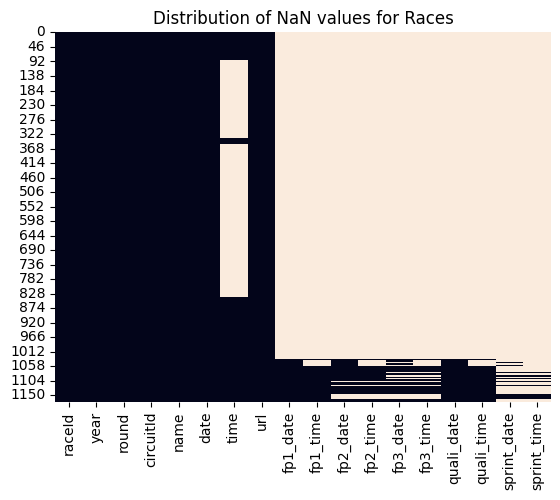

In [39]:
plt.xlabel("Field")
plt.ylabel("Index")
plt.title("Distribution of NaN values for Races")
sns.heatmap(race_df.isna(), cbar=False)

There is a big chunk of time data missing in the middle, but considering that it is the time that the race is run it will likely have minimal impact on our analysis. FP1-3 times, qualifying and sprint times are also spotty or missing in older data because they were not recorded or did not exist but this is fine as we're largely only interested in race times.

Sprint/Quali times could have an impact on our analysis but because we don't have them and there are a huge amount of rows missing we will leave these

#### Qualifying Data

In [40]:
quali_df.describe()

,qualifyId,raceId,driverId,constructorId,number,position
count,11036.000000,11036.000000,11036.000000,11036.000000,11036.000000,11036.000000
mean,5535.546394,650.800109,363.637731,50.285792,19.383925,11.162650
std,3204.812742,433.270591,394.617153,74.971061,18.946031,6.239336
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000
25%,2760.750000,191.000000,17.000000,5.000000,7.000000,6.000000
50%,5520.500000,882.000000,67.000000,10.000000,15.000000,11.000000
75%,8300.250000,1027.000000,826.000000,51.000000,23.000000,16.000000
max,11093.000000,1171.000000,866.000000,217.000000,99.000000,28.000000


In [41]:
res_df.isna().sum()

resultId               0
raceId                 0
driverId               0
constructorId          0
number                 6
grid                  20
position           10953
positionText           0
positionOrder          0
points                 0
laps                   0
time               19252
milliseconds       19252
fastestLap         18535
rank               18277
fastestLapTime     18535
fastestLapSpeed    19052
statusId               0
dtype: int64

<Axes: title={'center': 'Distribution of NaN values for Results'}>

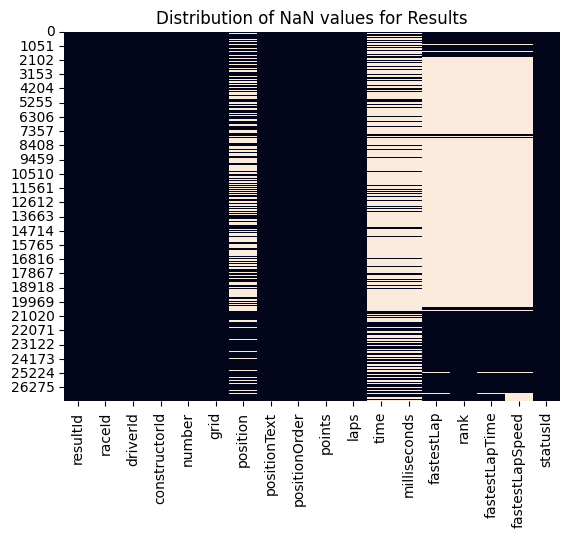

In [42]:
plt.xlabel("Field")
plt.ylabel("Index")
plt.title("Distribution of NaN values for Results")
sns.heatmap(res_df.isna(), cbar=False)

Time and milliseconds are missing on most of the data. There are huge gaps missing for fastestLap, rank and fastestLapSpeed so we likely won't be able to use these or infer them without skewing the analysis too much. Position does have a lot of NaN values but if we assume that this is down to some form of DNF then we can still infer results from this based on the linked statusId. This needs a bit more investigation

#### Constructor Data

In [43]:
constructor_df.describe()

,constructorId
count,214.000000
mean,108.565421
std,62.550133
min,1.000000
25%,55.250000
50%,108.500000
75%,161.750000
max,217.000000


In [44]:
constructor_df.isna().sum()

constructorId     0
constructorRef    0
name              0
nationality       0
url               0
dtype: int64

Nothing missing here so we can just move on

#### Driver Data

In [45]:
drivers_df.describe()

,driverId,number,dob
count,865.000000,63.000000,865
mean,433.065896,32.825397,1942-01-10 19:25:19.075144448
min,1.000000,2.000000,1896-12-28 00:00:00
25%,217.000000,10.500000,1923-01-21 00:00:00
50%,433.000000,24.000000,1937-02-20 00:00:00
75%,649.000000,44.500000,1958-02-18 00:00:00
max,866.000000,99.000000,2007-08-08 00:00:00
std,249.955064,28.295982,NaN


In [46]:
drivers_df.isna().sum()

driverId         0
driverRef        0
number         802
code           757
forename         0
surname          0
dob              0
nationality      0
url              0
dtype: int64

Some of the driver numbers and codes are missing, but we'll likely not use these anyway in our analysis so not much point digging into them

#### Race Status Lookup Data

In [47]:
status_df.describe()

,statusId
count,140.000000
mean,71.742857
std,41.378820
min,1.000000
25%,35.750000
50%,72.500000
75%,107.250000
max,142.000000


In [48]:
status_df.isna().sum()

statusId    0
status      0
dtype: int64

This is a lookup table with nothing missing, so again there isn't really a point digging into this one.

### Feature Analysis

So we've had a look at the quality of the data, we intentionally haven't had a look at the distribution of the features however yet though because we don't really know what would be useful, and it's quite a large feature set. Instead what we're going to do is pick some features that we think intuitively might be interesting for further exploration.

One thing though is that we're going to use 2025 as our test set, so we don't really want to be looking at races after 2024 during our EDA and feature analysis as really it's a mild form of leakage


In [49]:
race_df = race_df[race_df["year"] < 2025]
res_df = res_df[res_df["raceId"].isin(race_df["raceId"])]
quali_df = quali_df[quali_df["raceId"].isin(race_df["raceId"])]

#### Constructor Dominance

One of the common themes with F1 is that constructors go through periods of dominance, it could be a combination of driver, car and research but everyone knows the different eras in which *only* that team seemed to win, if we can find some patterns within this data we can identify that the constructor must be having an influence over if a driver gets a podium or not.

In [50]:
constructor_race_df = pd.merge(
    left=race_df[["raceId","year","round"]], 
    right=res_df[["raceId","constructorId","grid","position"]],
    how='left',
    left_on=["raceId"],
    right_on=["raceId"],
)
constructor_race_df

,raceId,year,round,constructorId,grid,position
0,1,2009,1,23,1.0,1.0
1,1,2009,1,23,2.0,2.0
2,1,2009,1,7,20.0,3.0
3,1,2009,1,7,19.0,4.0
4,1,2009,1,4,10.0,5.0
...,...,...,...,...,...,...
26754,1144,2024,24,210,14.0,16.0
26755,1144,2024,24,215,12.0,17.0
26756,1144,2024,24,15,9.0,NaN
26757,1144,2024,24,3,20.0,NaN


Joining on the constructor table to fetch the constructor name as well

In [51]:
constructor_race_df = pd.merge(
    left=constructor_race_df, 
    right=constructor_df[["constructorId", "name"]],
    how='left',
    left_on=["constructorId"],
    right_on=["constructorId"],
)
constructor_race_df

,raceId,year,round,constructorId,grid,position,name
0,1,2009,1,23,1.0,1.0,Brawn
1,1,2009,1,23,2.0,2.0,Brawn
2,1,2009,1,7,20.0,3.0,Toyota
3,1,2009,1,7,19.0,4.0,Toyota
4,1,2009,1,4,10.0,5.0,Renault
...,...,...,...,...,...,...,...
26754,1144,2024,24,210,14.0,16.0,Haas F1 Team
26755,1144,2024,24,215,12.0,17.0,RB F1 Team
26756,1144,2024,24,15,9.0,NaN,Sauber
26757,1144,2024,24,3,20.0,NaN,Williams


We look for all the constructors that have had any position in the top 3 grouped by year

In [ ]:
constructor_podium_df = pd.DataFrame(constructor_race_df[constructor_race_df["position"] <= 3].groupby(by=["year", "name"])["raceId"].count())

pivot_constructor_df = pd.pivot_table(constructor_podium_df, index="year", columns=["name"], values='raceId').fillna(0)

pivot_constructor_df.loc[:, pivot_constructor_df.sum(axis=0) > 20]
pivot_constructor_df


name,Alfa Romeo,AlphaTauri,Alpine F1 Team,Arrows,Aston Martin,BAR,BMW Sauber,BRM,Benetton,Brabham,...,Talbot-Lago,Team Lotus,Toleman,Toro Rosso,Toyota,Tyrrell,Vanwall,Watson,Williams,Wolf
year,,,,,,,,,,,,,,,,,,,,,
1950,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1951,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1952,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1953,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1954,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2021,0.0,1.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2022,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Plotting this out we can see clear patterns from the data, however. It's very crowded

Text(0.5, 1.0, 'More than 20 podiums for constructor')

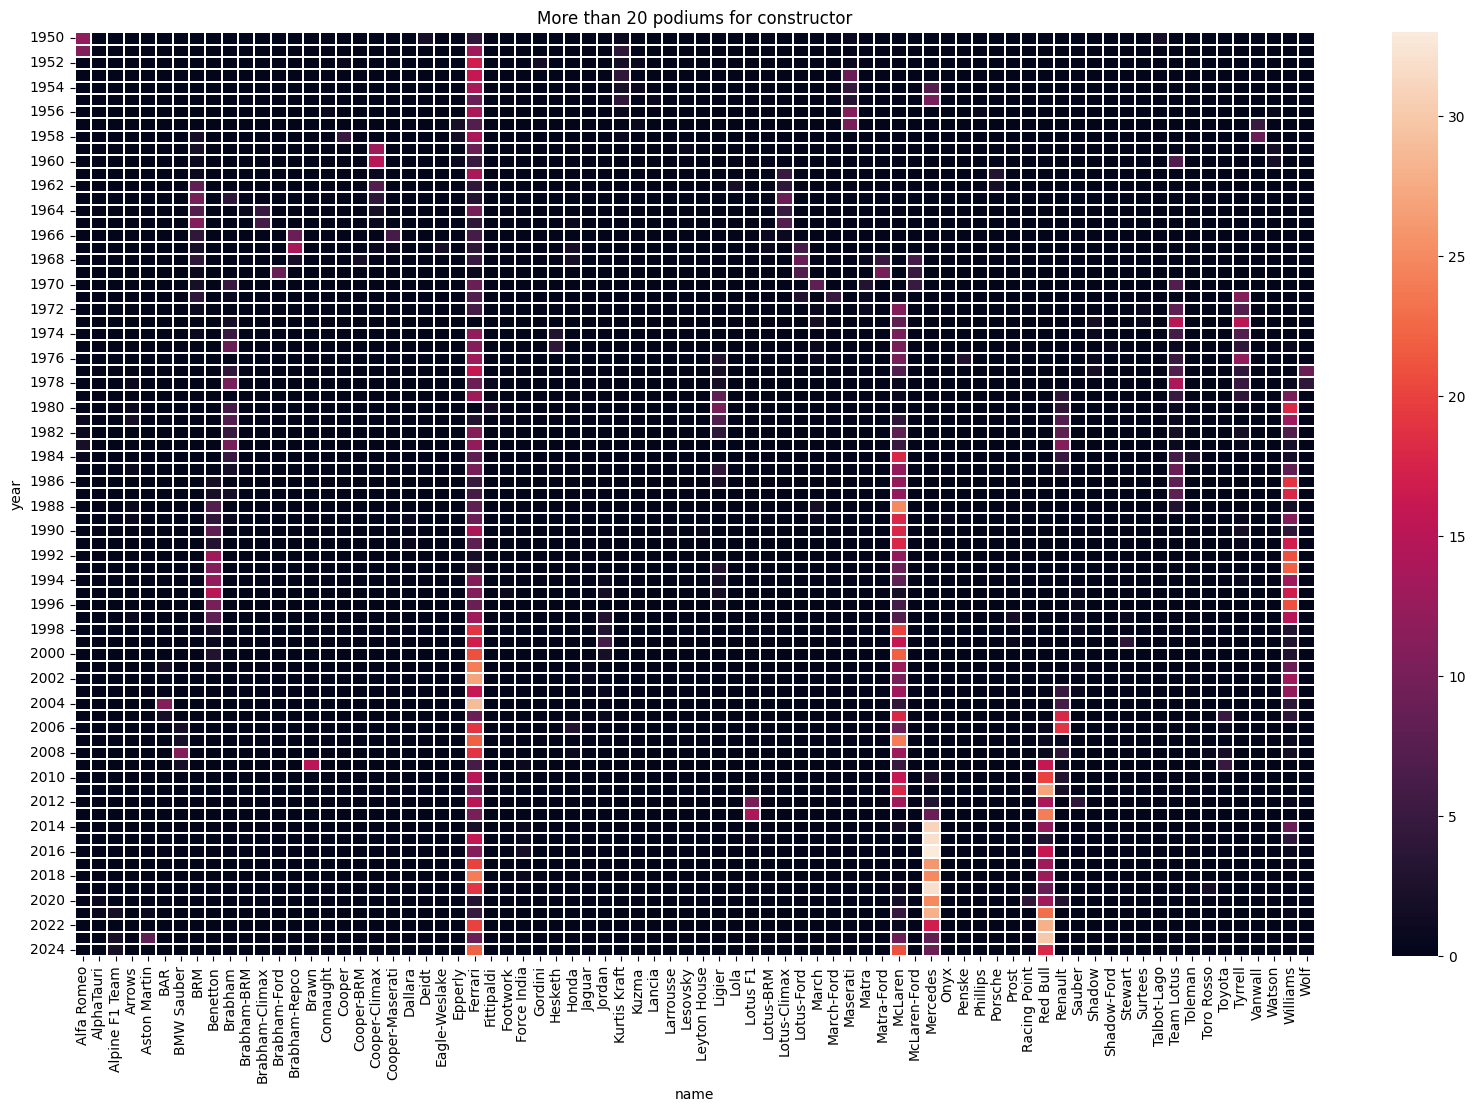

In [58]:
fig = plt.figure(figsize=(20, 12))
sns.heatmap(pivot_constructor_df, linewidths=0.1).set_title("More than 20 podiums for constructor")

What we can do instead is say that, we'll only look at constructors that have had atleast 10 podiums since 1990. This should cut out most of the noise and help us find signficant signals

In [61]:
after_1990_constructor_podiums_df = pivot_constructor_df.loc[pivot_constructor_df.index > 1990]
filtered_pivot_df = pivot_constructor_df.loc[:, after_1990_constructor_podiums_df.sum(axis=0) > 10]
filtered_pivot_df

name,BAR,BMW Sauber,Benetton,Brawn,Ferrari,Jordan,Lotus F1,McLaren,Mercedes,Red Bull,Renault,Toyota,Williams
year,,,,,,,,,,,,,
1950,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1951,0.0,0.0,0.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1952,0.0,0.0,0.0,0.0,17.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1953,0.0,0.0,0.0,0.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1954,0.0,0.0,0.0,0.0,14.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020,0.0,0.0,0.0,0.0,3.0,0.0,0.0,2.0,25.0,13.0,3.0,0.0,0.0
2021,0.0,0.0,0.0,0.0,5.0,0.0,0.0,5.0,28.0,23.0,0.0,0.0,1.0
2022,0.0,0.0,0.0,0.0,20.0,0.0,0.0,1.0,17.0,28.0,0.0,0.0,0.0


<Axes: title={'center': 'More than 10 podiums for constructor since 1990'}, xlabel='name', ylabel='year'>

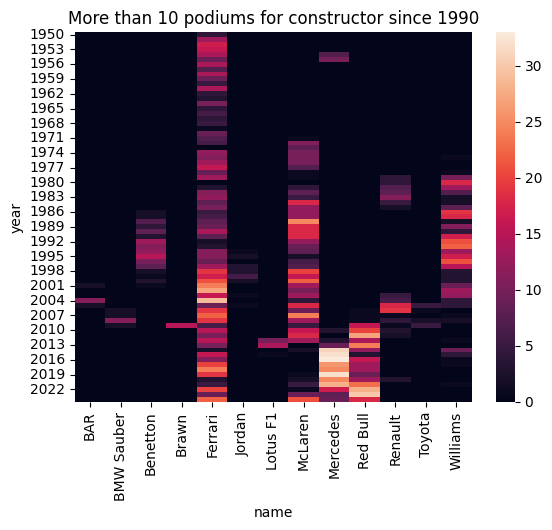

In [62]:
plt.title("More than 10 podiums for constructor since 1990")
sns.heatmap(filtered_pivot_df)

Here we get some really nice patterns, the wins are not evenly distributed amongst the constructors. We can clear see clear patterns of periods of dominance and then loss - for example williams have a very strong period in the 90's and Mercedes has only really become dominant after the 2010's.

Overall this means that there is something about the constructor that could have strong predictive power of podiums here, *but* we have to be careful as the driver is a strong confounding factor. For example we can't easily answer the question "Did they win because they had a great car? Or a great driver?" without unpacking a lot of the data even more


#### Qualifying Position vs Finish Position Over Time

Another thing to consider might be, how has the relationship changed over time? For example, were lighter, smaller cars before easier to overtake in? And therefore a qualifying position was less an advantage as compared to now?

We can find this out by measuring the mean absolute difference between grid start and finish position over time.

In [64]:
position_over_time_df = pd.merge(
    left=race_df[["raceId", "year"]],
    right=res_df[["raceId", "driverId", "grid", "position"]],
    how="left",
    on="raceId"
).dropna().reset_index(drop=True)

position_over_time_df["absPositionDifference"] = abs(position_over_time_df["grid"] - position_over_time_df["position"])

position_difference_by_year_df = pd.DataFrame(position_over_time_df.groupby("year").mean()["absPositionDifference"])
position_difference_by_year_df

,absPositionDifference
year,
1950,5.759036
1951,4.477778
1952,5.448276
1953,5.795276
1954,6.927273
...,...
2020,3.285714
2021,2.974227
2022,3.393617


By plotting this onto a graph, and also fitting a linear trend line to the data we can see that the position difference definitely is shrinking over time from roughly 6 positions difference in the 90's to roughly 3 now

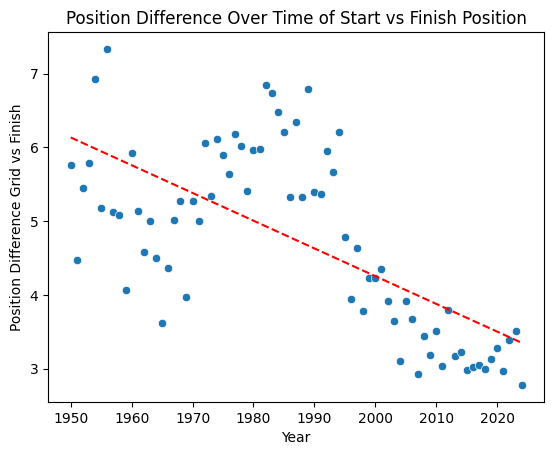

In [65]:
plt.xlabel("Year")
plt.ylabel("Position Difference Grid vs Finish")
plt.title("Position Difference Over Time of Start vs Finish Position")

trend = np.polyfit(position_difference_by_year_df.index, position_difference_by_year_df["absPositionDifference"], 1)
trendpoly = np.poly1d(trend) 

sns.scatterplot(data=position_difference_by_year_df, x=position_difference_by_year_df.index, y="absPositionDifference")
plt.plot(position_difference_by_year_df.index, trendpoly(position_difference_by_year_df.index), color="red", linestyle='dashed')

There is a big consideration to make here though, that *we don't consider DNF's*. So it might be that cars today are much more ureliable or there is more lapping going on than there was in the 90's it is not necessarily the case that the grid is locked into place from qualifying as this may suggest.

#### Podium Rates per Driver

Another factor to consider is driver skill. Do some drivers have stronger podium rates than other drivers? We use a ratio here of count of podiums over total races because otherwise if we did an absolute count then a driver with a longer career and more races would be unfairly pushed to the top of the ranking, or is more likely to be represented there.

In [66]:
driver_position_df = res_df[["raceId","driverId", "position"]]
driver_position_df["podium"] = np.where(driver_position_df["position"] <= 3, 1, 0)
driver_position_df = pd.DataFrame(driver_position_df.groupby("driverId").agg({"podium": ["sum", "mean"], "raceId": "count"})).reset_index()
driver_position_df.columns = ["driverId", "podium_count", "podium_rate", "race_count"]

driver_position_df = driver_position_df.sort_values("podium_rate", ascending=False)

driver_position_df

/tmp/ipykernel_110709/1536547364.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  driver_position_df["podium"] = np.where(driver_position_df["position"] <= 3, 1, 0)


,driverId,podium_count,podium_rate,race_count
801,802,1,1.000000,1
590,591,1,1.000000,1
785,786,6,0.750000,8
578,579,35,0.603448,58
0,1,202,0.567416,356
...,...,...,...,...
353,354,0,0.000000,2
354,355,0,0.000000,1
356,357,0,0.000000,15
361,362,0,0.000000,4


However, we also have to consider the absolute count as well because a driver who only participates in a single race and never races again would have a podium rate of 100%, it doesn't mean they're a perfect driver, it meant that they quit while they were ahead. For example in our previous example, drivers 801 and 591 raced in one race, had a podium and then left.

What we do to mitigate this is to also have the condition that the driver must also race for atleast 24 races.

In [67]:
driver_position_df = pd.merge(
    left=driver_position_df,
    right=drivers_df[["forename", "surname", "driverId"]],
    on="driverId"
)

driver_position_df["name"] = driver_position_df["forename"] + " " + driver_position_df["surname"]
driver_position_df = driver_position_df.drop(columns=["forename", "surname"])

driver_position_df.head()

,driverId,podium_count,podium_rate,race_count,name
0,802,1,1.000000,1,Dorino Serafini
1,591,1,1.000000,1,George Amick
2,786,6,0.750000,8,Luigi Fagioli
3,579,35,0.603448,58,Juan Fangio
4,1,202,0.567416,356,Lewis Hamilton


In [68]:
min_24_races_driver_position_df = driver_position_df[driver_position_df["race_count"] > 24]
min_24_races_driver_position_df = min_24_races_driver_position_df.sort_values("podium_rate", ascending=False)
min_24_races_driver_position_df

,driverId,podium_count,podium_rate,race_count,name
3,579,35,0.603448,58,Juan Fangio
4,1,202,0.567416,356,Lewis Hamilton
5,642,20,0.540541,37,Nino Farina
6,830,112,0.535885,209,Max Verstappen
7,117,106,0.524752,202,Alain Prost
...,...,...,...,...,...
703,437,0,0.000000,26,Ian Burgess
777,307,0,0.000000,39,Howden Ganley
808,290,0,0.000000,38,Wilson Fittipaldi
826,329,0,0.000000,29,Mike Beuttler


<Axes: title={'center': 'Top 25 Podium Rates Per Driver'}, xlabel='Podium Rate', ylabel='Driver Name'>

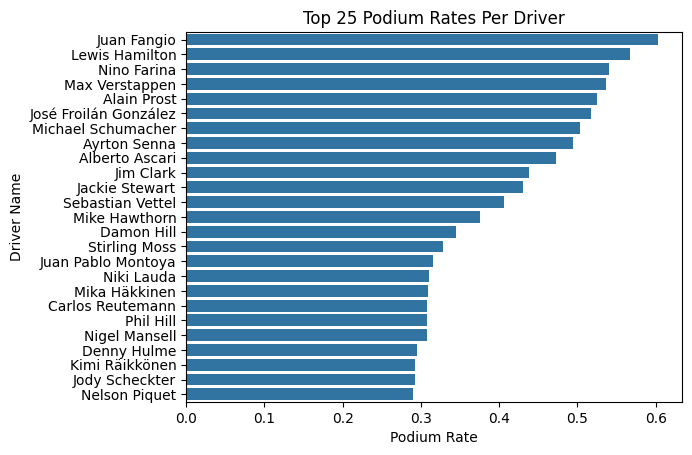

In [69]:
plt.title("Top 25 Podium Rates Per Driver")
plt.xlabel("Podium Rate")
plt.ylabel("Driver Name")

sns.barplot(min_24_races_driver_position_df[:25], x="podium_rate", y="name")

We only look at the top 25 drivers but we can see that there are strong results of podium rates for these specific drivers, but also diversity. To contrast it we shall also look at the bottom 25 drivers. One of the things we will remove from our analysis is drivers that never had a podium, they are interesting cases but purely for our goal of looking at podium rates they are noise.

In [70]:
print("Number of drivers who never had a podium:",len(min_24_races_driver_position_df[min_24_races_driver_position_df["podium_rate"] == 0])) 

Number of drivers who never had a podium: 88


<Axes: title={'center': 'Bottom 25 Podium Rates Per Driver'}, xlabel='Podium Rate', ylabel='Driver Name'>

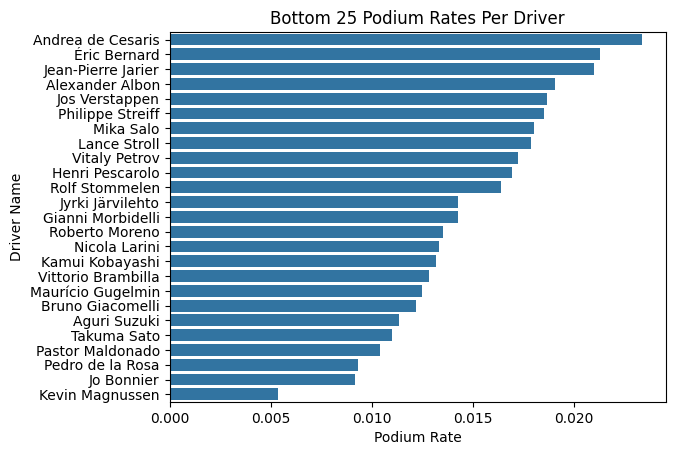

In [71]:
plt.title("Bottom 25 Podium Rates Per Driver")
plt.xlabel("Podium Rate")
plt.ylabel("Driver Name")

sns.barplot(min_24_races_driver_position_df[min_24_races_driver_position_df["podium_rate"] > 0][-25:], x="podium_rate", y="name")

In conclusion, *yes* there doesn appear to be a strong difference in podium rates between drivers. But as we alluded to before this could be related to the confounding variable of the constructor - you could make a strong argument that a driver in a Williams who achieves 3rd is a much more skilled driver than a driver in a Mercedes who achieves 2nd for example.